In [1]:
import pandas as pd
d1=pd.read_csv("healthy_motor_data.csv")
d2=pd.read_csv("sick_motor_phaseAshort.csv")
d3=pd.read_csv("sick_motor_phaseBshort.csv")
d4=pd.read_csv("sick_motor_phasecshort.csv")
d5=pd.read_csv("sick_motor_brokenrotorbar.csv")
d1["label"]=0
d2["label"]=1
d3["label"]=2
d4["label"]=3
d5["label"]=4
df1=pd.concat([d1,d2,d3,d4,d5],ignore_index=True)
df1=df1.sample(frac=1).reset_index(drop=True)
#df1.to_csv("combined.csv",index=True)

print data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300684 entries, 0 to 300683
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    300684 non-null  float64
 1   Ia      300684 non-null  float64
 2   Ib      300684 non-null  float64
 3   Ic      300684 non-null  float64
 4   Speed   300684 non-null  float64
 5   label   300684 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 13.8 MB
is the data null


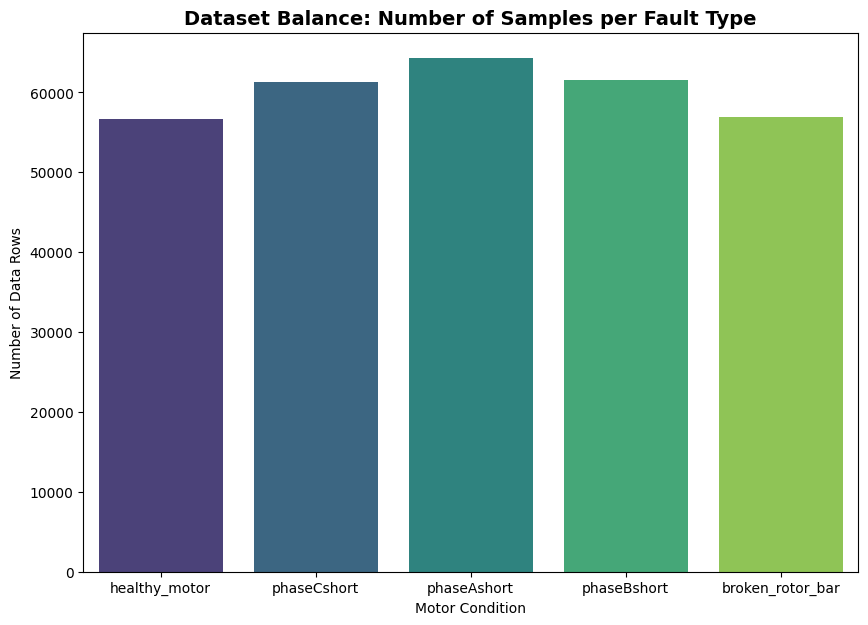

In [2]:
import matplotlib.pyplot  as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("print data info")
df1.info()
print("is the data null")
df1.isnull().sum()
sns.set_theme="darkgrid"
label_names={0:"healthy_motor",1:"phaseAshort",2:"phaseBshort",3:"phaseCshort",4:"broken_rotor_bar"}
df1['fault_name'] = df1['label'].map(label_names)
plt.figure(figsize=(10,7))
sns.countplot(data=df1,x="fault_name",palette='viridis')
plt.title('Dataset Balance: Number of Samples per Fault Type', fontsize=14, fontweight='bold')
plt.ylabel('Number of Data Rows')
plt.xlabel('Motor Condition')
plt.show()



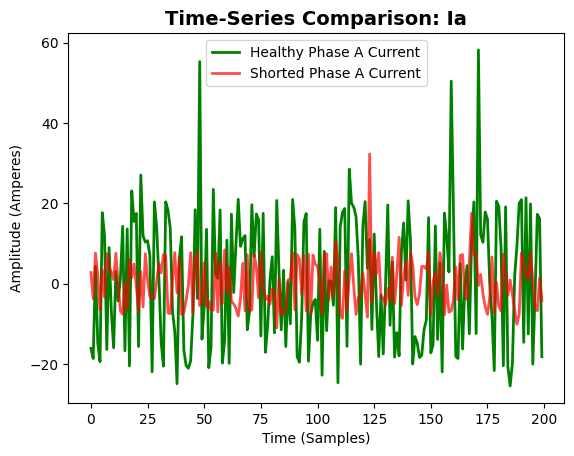

In [3]:
healthy_motor=df1[df1['label']==0]['Ia'].head(200).values
phaseAshort=df1[df1['label']==1]['Ia'].head(200).values
plt.plot(healthy_motor, label='Healthy Phase A Current', color='green', linewidth=2)
plt.plot(phaseAshort, label='Shorted Phase A Current', color='red', alpha=0.7, linewidth=2)
plt.title(f'Time-Series Comparison: {'Ia'}', fontsize=14, fontweight='bold')
plt.xlabel('Time (Samples)')
plt.ylabel('Amplitude (Amperes)')
plt.legend()
plt.show()

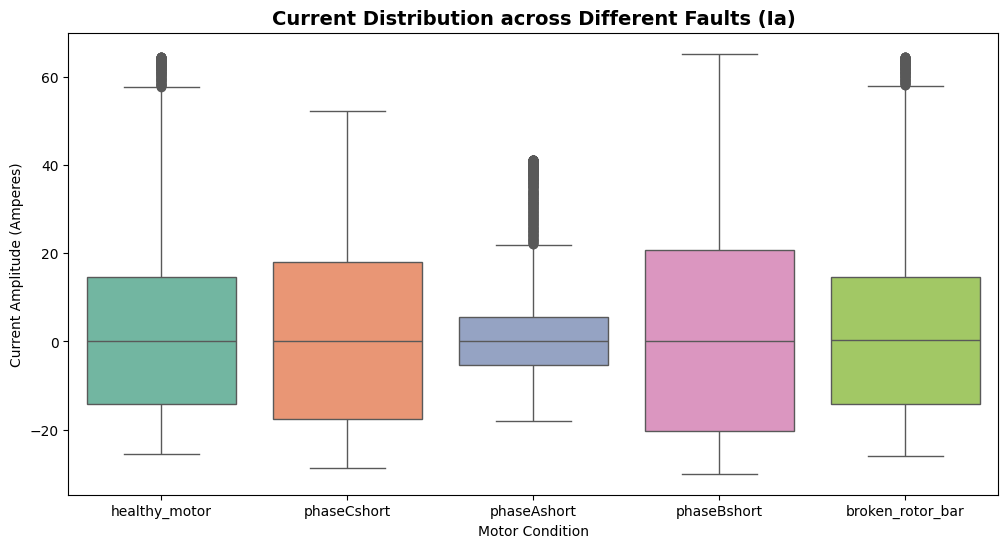

In [4]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df1, x='fault_name', y='Ia', palette='Set2')
plt.title(f'Current Distribution across Different Faults ({'Ia'})', fontsize=14, fontweight='bold')
plt.ylabel('Current Amplitude (Amperes)')
plt.xlabel('Motor Condition')
plt.show()

In [5]:
import numpy as np
window_size = 1000
features_list = []
inputs = ['Ia', 'Ib', 'Ic','Speed']
for label in df1['label'].unique():
    
    fault_data = df1[df1['label'] == label]
    num_windows = len(fault_data) // window_size
    
    for i in range(num_windows):
        start_idx = i * window_size
        end_idx = start_idx + window_size
        
       
        window_features = {'Label': label}
        
      
        for inp in inputs:
            window = fault_data[inp].values[start_idx:end_idx]
            window_features[f'{inp}_Mean'] = np.mean(window)
            window_features[f'{inp}_Std'] = np.std(window)
            window_features[f'{inp}_Max'] = np.max(window)
            window_features[f'{inp}_Min'] = np.min(window)
            window_features[f'{inp}_Peak2Peak'] = np.max(window) - np.min(window)
            window_features[f'{inp}_RMS'] = np.sqrt(np.mean(window**2))
          
            
        features_list.append(window_features)


features_df = pd.DataFrame(features_list)
features_df=features_df.sample(frac=1).reset_index(drop=True)
features_df.to_csv('ai_ready_features_3phase.csv', index=False)

model accuracy: 100.00%
Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        12
           3       1.00      1.00      1.00        13
           4       1.00      1.00      1.00        11

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



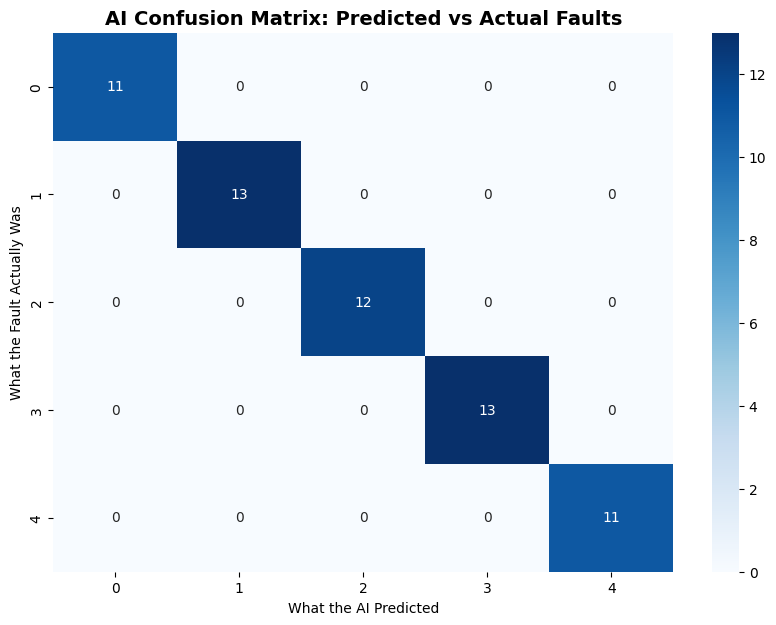

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot  as plt
import seaborn as sns
df = pd.read_csv('ai_ready_features_3phase.csv')
X = df.drop('Label', axis=1) 
y = df['Label']               
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"model accuracy: {accuracy * 100:.2f}%")

print("Detailed Classification Report:")
print(classification_report(y_test, predictions))

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('AI Confusion Matrix: Predicted vs Actual Faults', fontsize=14, fontweight='bold')
plt.xlabel('What the AI Predicted')
plt.ylabel('What the Fault Actually Was')
plt.show()

In [7]:
import joblib
joblib.dump(model, 'motor_fault_detection_model.pkl')

print(" Model successfully packed and saved to disk!")

 Model successfully packed and saved to disk!


In [8]:
import joblib
import pandas as pd
import numpy as np

model = joblib.load('motor_fault_detection_model.pkl')

print(" AI successfully unpacked and ready for testing!")

 AI successfully unpacked and ready for testing!


In [9]:
import numpy as np
import pandas as pd

def predict_from_raw_sensor_data(raw_data_df, trained_model,sampling_rate=10000):
        
    
    live_features = {}
    phases = ['Ia', 'Ib', 'Ic','Speed']
    
    
    current_state = None
    state_start_time = 0.0
    timeline = []
    has_time_col = 'Time' in raw_data_df.columns
    if has_time_col:
            current_time = raw_data_df['Time'].iloc[start_idx]
            end_time = raw_data_df['Time'].iloc[end_idx - 1]
    else:
        current_time = start_idx / sampling_rate
        end_time = end_idx / sampling_rate
    
    for phase in phases:
        window = raw_data_df[phase].values
        
        live_features[f'{phase}_Mean'] = np.mean(window)
        live_features[f'{phase}_Std'] = np.std(window)
        live_features[f'{phase}_Max'] = np.max(window)
        live_features[f'{phase}_Min'] = np.min(window)
        live_features[f'{phase}_Peak2Peak'] = np.max(window) - np.min(window)
        live_features[f'{phase}_RMS'] = np.sqrt(np.mean(window**2))
   
    ai_ready_input = pd.DataFrame([live_features])
    
   
    prediction = trained_model.predict(ai_ready_input)[0]
    
   
    labels = {0: 'Healthy', 1: 'Phase A Short', 2: 'Phase B Short', 
              3: 'Phase C Short', 4: 'Broken Rotor Bar'}
              
    predicted_label = labels.get(prediction, "Unknown")
        
    if current_state is None:
        current_state = predicted_label
        state_start_time = current_time
            
    elif predicted_label != current_state:
        if "Healthy" in current_state:
            timeline.append(f"From {state_start_time:.3f}s to {current_time:.3f}s --> No fault occurred ({current_state})")
        else:
            timeline.append(f"From {state_start_time:.3f}s to {current_time:.3f}s --> Fault occurred: {current_state}")
        current_state = predicted_label
        state_start_time = current_time
    if "Healthy" in current_state:
        timeline.append(f"From {state_start_time:.3f}s to {end_time:.3f}s --> No fault occurred ({current_state})")
    else:
        timeline.append(f"From {state_start_time:.3f}s to {end_time:.3f}s --> Fault occurred: {current_state}")
    print("\n=======================================================")
    print("📊 DYNAMIC FAULT TIMELINE")
    print("=======================================================")
    for event in timeline:
        print(event)
    print("=======================================================\n")      
    
user_df = pd.read_csv('Motor_Dynamic_Fault.csv')
predict_from_raw_sensor_data(user_df, model)


📊 DYNAMIC FAULT TIMELINE
From 1.881s to 1.915s --> Fault occurred: Broken Rotor Bar

